# Seasonal Agriculture Performance Analysis

**Objective:** Analyze agricultural data across seasons to identify meaningful patterns, differences, relationships, and insights that can support seasonal agricultural planning.

This notebook follows the analytical areas given in the project PDF and uses simple statistical summaries and visualizations.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [28]:
print(df.shape)
df.info()
print(df.columns)
print("\nSeason counts:")
print(df["Season"].value_counts())
print("\nCrop counts:")
print(df["Crop"].value_counts())
print("\nIrrigation method counts:")
print(df["Irrigation_Method"].value_counts())

(4000, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 n

In [29]:
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

print("Duplicate records:", df.duplicated().sum())

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64
Duplicate records: 0


In [32]:
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].median())
df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(
    df["Soil_Moisture_pct"].median()
)
df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(
    df["Yield_Tonnes_Ha"].median()
)

print("Remaining missing values:", df.isnull().sum().sum())
print("Remaining duplicate records:", df.duplicated().sum())
df.describe()

Remaining missing values: 0
Remaining duplicate records: 0


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


## Q1. How does agricultural performance vary across seasons?

In [33]:
season_summary = df.groupby("Season")[[
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Profit_INR",
    "Water_Efficiency_t_per_1000m3"
]].mean()

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Efficiency_t_per_1000m3
Season,,,,,
Kharif,5.628612,46.311192,710719.055649,178914.647555,5.891834
Rabi,5.039435,41.486712,601526.048556,87689.470191,5.186122
Zaid,4.641313,38.886111,519171.904040,-24804.824916,4.413239


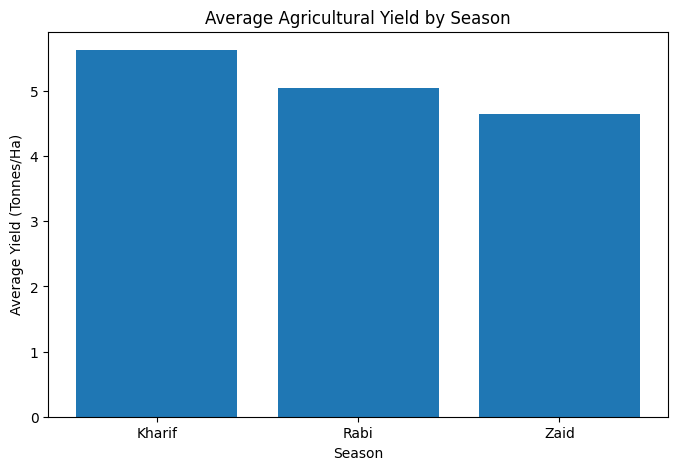

In [34]:
plt.figure(figsize=(8, 5))
plt.bar(season_summary.index, season_summary["Yield_Tonnes_Ha"])
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.title("Average Agricultural Yield by Season")
plt.show()

Kharif records the highest average yield, while Zaid records the lowest. Rabi falls between the two seasons.

## Q2. What major seasonal patterns can be observed?

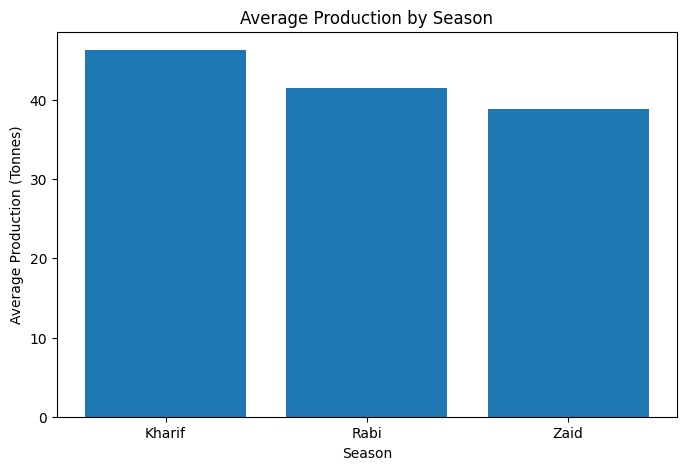

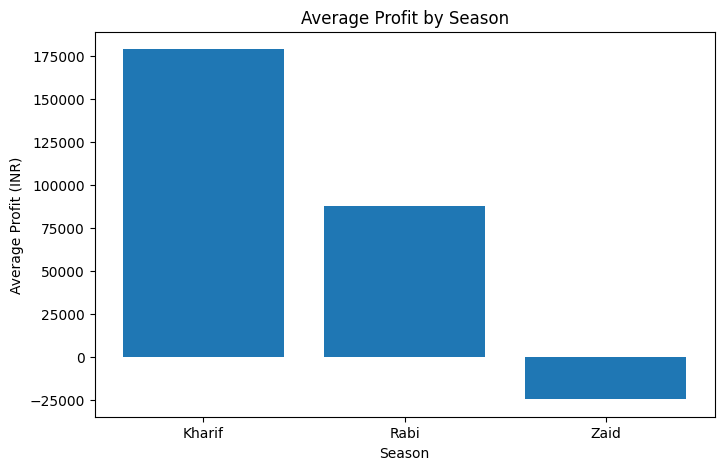

In [35]:
plt.figure(figsize=(8, 5))
plt.bar(season_summary.index, season_summary["Production_Tonnes"])
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")
plt.title("Average Production by Season")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(season_summary.index, season_summary["Profit_INR"])
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.title("Average Profit by Season")
plt.show()

Kharif has the highest average production and profit while Zaid has the lowest. Rabi stays in between the two seasons

## Q3. Which characteristics change between seasons?

In [36]:
season_environment = df.groupby("Season")[[
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct"
]].mean()

season_environment

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.199663,28.454019,71.812591,6.793367,31.149859
Rabi,437.615366,23.489183,57.893178,7.589797,24.069392
Zaid,304.654714,31.042088,52.012121,8.178788,19.279630


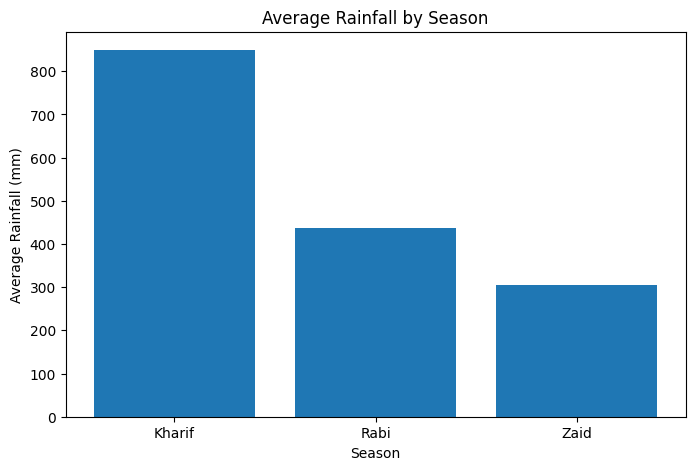

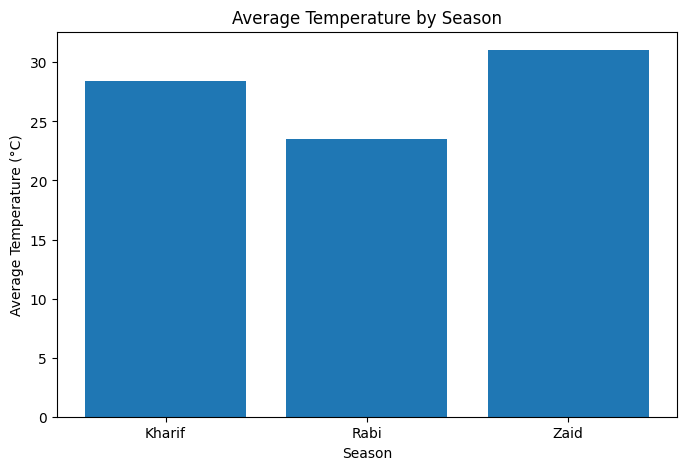

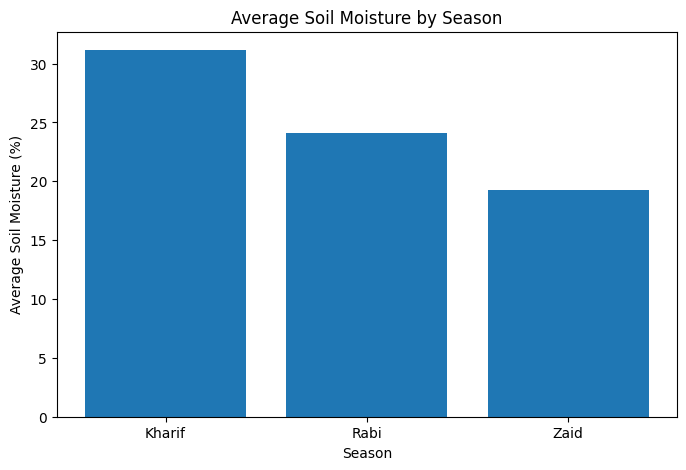

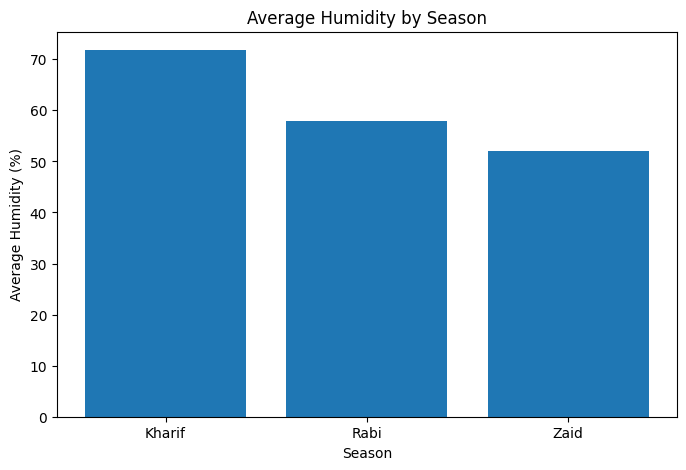

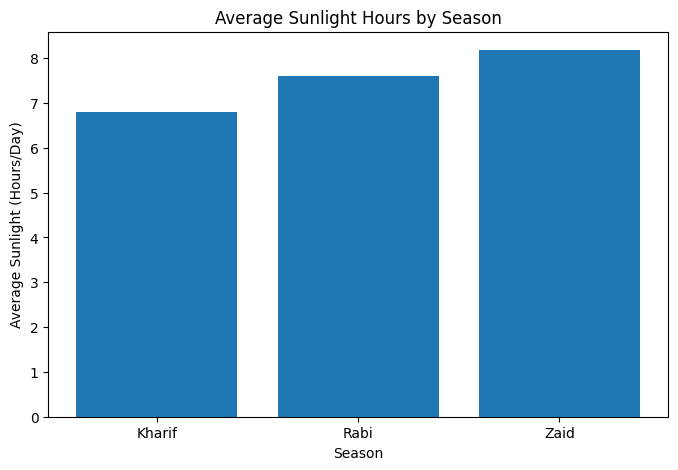

In [37]:
# Rainfall
plt.figure(figsize=(8, 5))
plt.bar(season_environment.index, season_environment["Rainfall_mm"])
plt.xlabel("Season")
plt.ylabel("Average Rainfall (mm)")
plt.title("Average Rainfall by Season")
plt.show()

# Temperature
plt.figure(figsize=(8, 5))
plt.bar(season_environment.index, season_environment["Avg_Temperature_C"])
plt.xlabel("Season")
plt.ylabel("Average Temperature (°C)")
plt.title("Average Temperature by Season")
plt.show()

# Soil moisture
plt.figure(figsize=(8, 5))
plt.bar(season_environment.index, season_environment["Soil_Moisture_pct"])
plt.xlabel("Season")
plt.ylabel("Average Soil Moisture (%)")
plt.title("Average Soil Moisture by Season")
plt.show()

# humidity
plt.figure(figsize=(8, 5))
plt.bar(season_environment.index,season_environment["Humidity_pct"])
plt.xlabel("Season")
plt.ylabel("Average Humidity (%)")
plt.title("Average Humidity by Season")
plt.show()

# sunlight hours
plt.figure(figsize=(8, 5))
plt.bar(season_environment.index,season_environment["Sunlight_Hours_Day"])
plt.xlabel("Season")
plt.ylabel("Average Sunlight (Hours/Day)")
plt.title("Average Sunlight Hours by Season")
plt.show()

Kharif has the highest rainfall, humidity, and soil moisture while Zaid has the highest temperature and sunlight hours. So environmental conditions changes between the three agricultural seasons.

## Q4. What differences exist between agricultural activities in different seasons?

In [38]:
crop_season_yield = df.groupby(
    ["Season", "Crop"]
)["Yield_Tonnes_Ha"].mean().unstack()

crop_season_yield

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,1.731459,1.374512,1.484974,2.966410,1.036063,2.698376,53.459120,2.253664
Rabi,1.465031,1.198358,1.233164,2.603648,0.875962,2.322847,43.286124,2.057468
Zaid,1.195312,0.960217,1.037778,2.290952,0.669677,1.900490,38.423922,1.748588


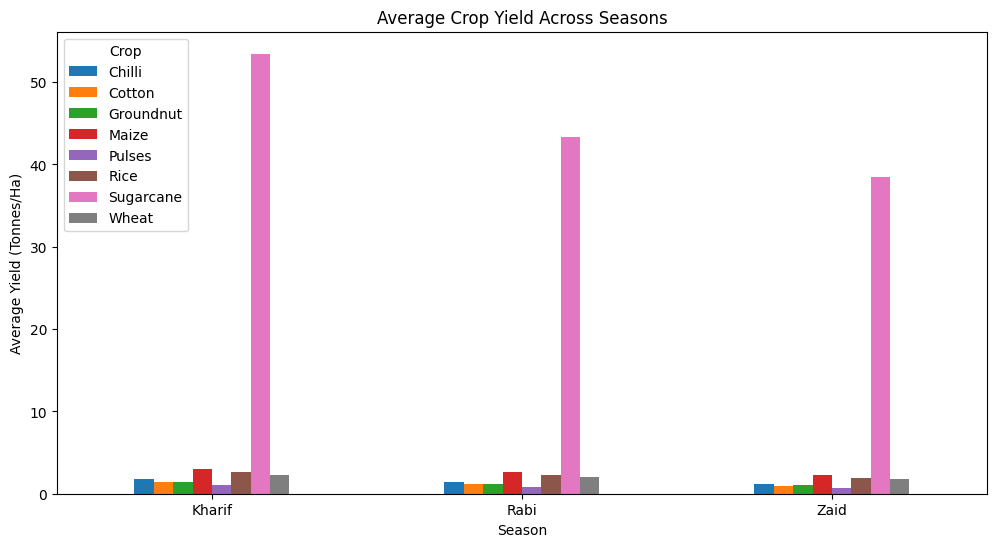

In [39]:
crop_season_yield.plot(kind="bar", figsize=(12, 6))
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.title("Average Crop Yield Across Seasons")
plt.xticks(rotation=0)
plt.legend(title="Crop")
plt.show()

Crop yieldschanges across seasons. Kharif shows higher values than Zaid. Sugarcane has the highest average yield among the crops in all 3 seasons.

## Q5. Are there noticeable variations in resource usage across seasons?

In [40]:
resource_summary = df.groupby("Season")[[
    "Fertilizer_kg_ha",
    "Water_Used_m3",
    "Pesticide_Litre_ha"
]].mean()

resource_summary

,Fertilizer_kg_ha,Water_Used_m3,Pesticide_Litre_ha
Season,,,
Kharif,187.077965,6102.201237,5.079747
Rabi,185.407068,5846.987093,5.024690
Zaid,184.638047,6419.893939,5.171212


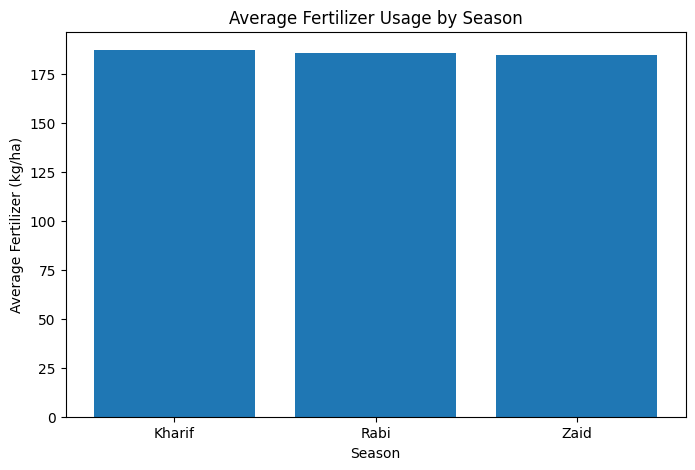

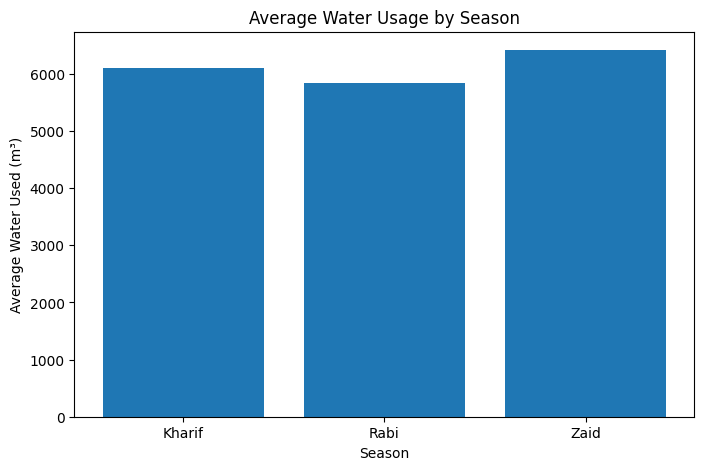

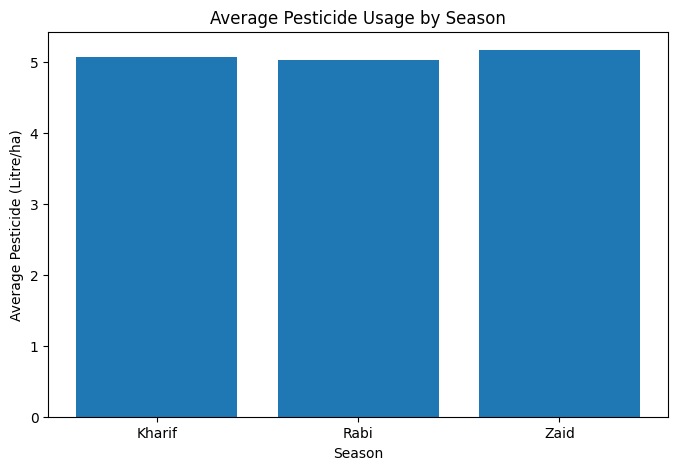

In [42]:
# Fertilizer
plt.figure(figsize=(8, 5))
plt.bar(resource_summary.index, resource_summary["Fertilizer_kg_ha"])
plt.xlabel("Season")
plt.ylabel("Average Fertilizer (kg/ha)")
plt.title("Average Fertilizer Usage by Season")
plt.show()

# Water usge
plt.figure(figsize=(8, 5))
plt.bar(resource_summary.index, resource_summary["Water_Used_m3"])
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")
plt.title("Average Water Usage by Season")
plt.show()

# Pesticide
plt.figure(figsize=(8, 5))
plt.bar(resource_summary.index, resource_summary["Pesticide_Litre_ha"])
plt.xlabel("Season")
plt.ylabel("Average Pesticide (Litre/ha)")
plt.title("Average Pesticide Usage by Season")
plt.show()

Kharif has the highest average fertilizer usage while Zaid uses the most water and pesticide. Rabi records the lowest water and pesticide usage

## Q6. Are there relationships between seasonal environmental conditions and agricultural performance?

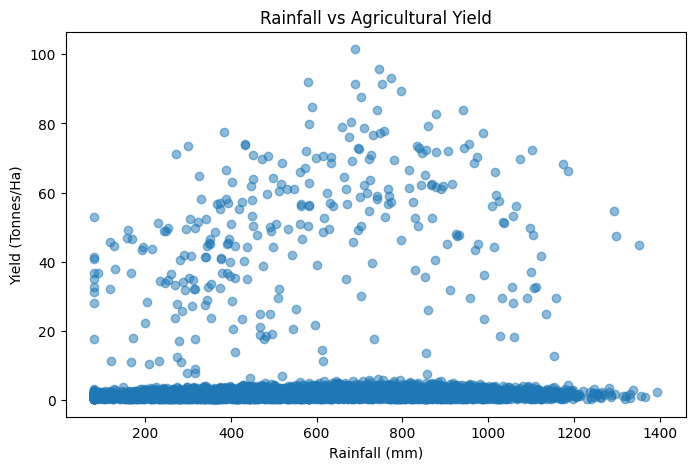

Rainfall-Yield correlation: 0.031


In [43]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Rainfall_mm"], df["Yield_Tonnes_Ha"], alpha=0.5)
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.title("Rainfall vs Agricultural Yield")
plt.show()

rainfall_yield_corr = df["Rainfall_mm"].corr(df["Yield_Tonnes_Ha"])
print("Rainfall-Yield correlation:", round(rainfall_yield_corr, 3))

In [44]:
# Correlation 
correlation_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_Moisture_pct",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

yield_correlations = (
    df[correlation_columns]
    .corr()["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
)

yield_correlations

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912568
Profit_INR                       0.488466
Rainfall_mm                      0.030951
Disease_Pest_Risk_pct            0.014292
Humidity_pct                     0.012297
Soil_Moisture_pct                0.010999
Avg_Temperature_C                0.009996
Fertilizer_kg_ha                 0.000018
Seed_Quality_Score              -0.007209
Pesticide_Litre_ha              -0.007779
Name: Yield_Tonnes_Ha, dtype: float64

Rainfall has almost no relationship with yield with a correlation about 0.03. Water efficiency has a strong positive relationship with yield while profit has a moderate positive relationship.

## Q7. How do economic outcomes vary across seasons?

In [45]:
economic_summary = df.groupby("Season")[[
    "Revenue_INR",
    "Total_Cost_INR",
    "Profit_INR"
]].mean()

economic_summary

,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,
Kharif,710719.055649,531804.408094,178914.647555
Rabi,601526.048556,513836.578365,87689.470191
Zaid,519171.904040,543976.728956,-24804.824916


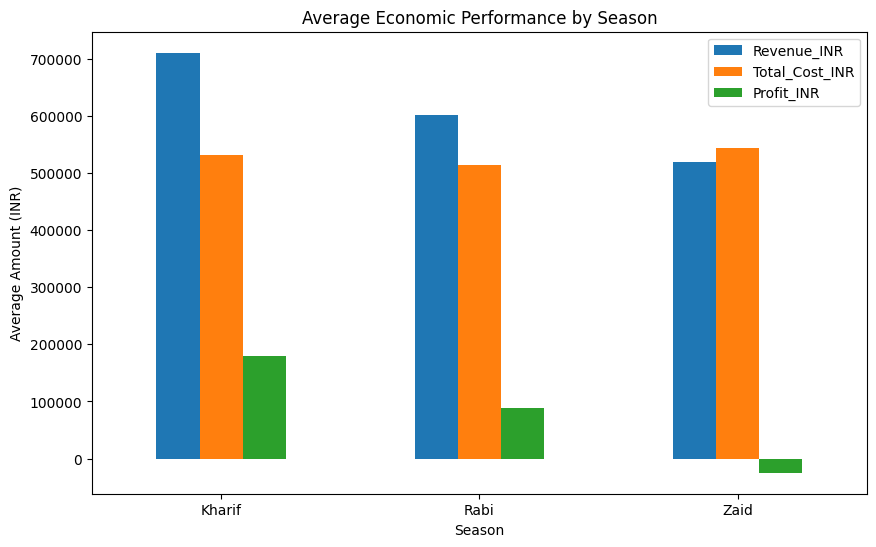

In [46]:
economic_summary.plot(kind="bar", figsize=(10, 6))
plt.xlabel("Season")
plt.ylabel("Average Amount (INR)")
plt.title("Average Economic Performance by Season")
plt.xticks(rotation=0)
plt.show()

Kharif records the highest average revenue and profit and Rabi records lower returns. Zaid has the lowest average revenue and a negative profit, showing weaker economic performance.

## Q8. Are some seasonal patterns consistent across different regions or categories?

In [47]:
regional_season_yield = df.groupby(
    ["State", "Season"]
)["Yield_Tonnes_Ha"].mean().unstack()

regional_season_yield

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.676958,3.470931,4.448000
Gujarat,6.338416,5.441700,4.066716
Karnataka,6.455024,4.567864,6.623243
Madhya Pradesh,5.985265,3.760385,5.478889
Maharashtra,5.430315,5.501927,2.277778
Punjab,4.100633,8.609355,5.909610
Tamil Nadu,5.520534,4.501394,4.097746
Telangana,5.552436,4.784569,4.248471


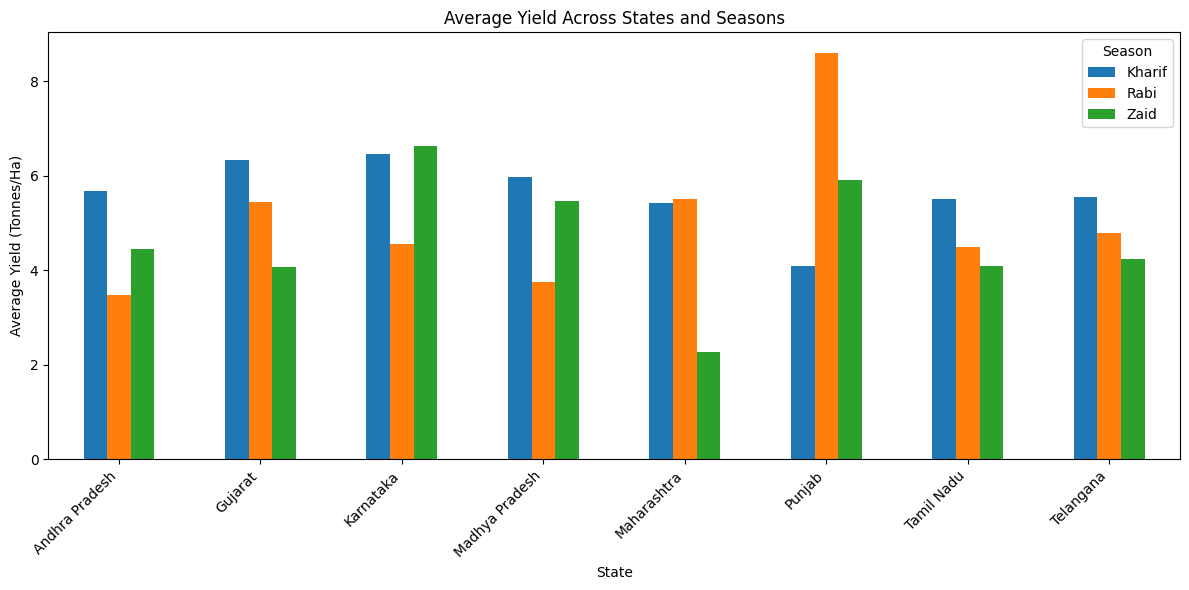

In [48]:
regional_season_yield.plot(kind="bar", figsize=(12, 6))
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.title("Average Yield Across States and Seasons")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

Seasonal yield patterns are not same in every state. Kharif is strongest in many states, but Rabi or Zaid performs better in some states, so regional conditions matter.

## Q9. Are there unusual or unexpected seasonal patterns?

In [49]:
state_best_season = regional_season_yield.idxmax(axis=1)
state_best_yield = regional_season_yield.max(axis=1)

unusual_state_patterns = pd.DataFrame({
    "Best_Season": state_best_season,
    "Average_Yield": state_best_yield})

unusual_state_patterns

,Best_Season,Average_Yield
State,,
Andhra Pradesh,Kharif,5.676958
Gujarat,Kharif,6.338416
Karnataka,Zaid,6.623243
Madhya Pradesh,Kharif,5.985265
Maharashtra,Rabi,5.501927
Punjab,Rabi,8.609355
Tamil Nadu,Kharif,5.520534
Telangana,Kharif,5.552436


<Figure size 800x500 with 0 Axes>

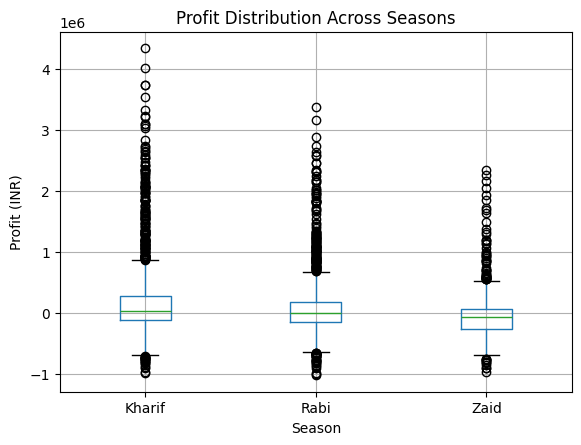

In [50]:
plt.figure(figsize=(8, 5))
df.boxplot(column="Profit_INR", by="Season")
plt.title("Profit Distribution Across Seasons")
plt.suptitle("")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.show()

Some states show unusual results because Rabi or Zaid becomes their best yielding season instead of Kharif. Zaid is also unusual because its average profit is negative despite having the highest average water and pesticide usage.

# Q10. What insights can be derived from the observed seasonal differences?

In [52]:
season_summary.round(2)

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Efficiency_t_per_1000m3
Season,,,,,
Kharif,5.63,46.31,710719.06,178914.65,5.89
Rabi,5.04,41.49,601526.05,87689.47,5.19
Zaid,4.64,38.89,519171.90,-24804.82,4.41


 Kharif shows the strongest overall agricultural and economic performance. Zaid has lower yield and profit and also uses more water and pesticide, making it less efficient

## Q11. What conclusions can reasonably be drawn from the available data?

Agricultural performance changes across seasons in terms of yield, production, resources, environmental conditions, and profit. These differences show that agricultural conditions vary between seasons.

## Q12. How could the findings support better seasonal agricultural planning?

This analysis shows that agricultural performance varies across seasons. Kharif had the strongest overall performance while Zaid had the weakest economic performance.Farmers can use better resource and crop selection based on environmental and economic conditions.They can also use these seasonal patterns to plan crops, water, fertilizer, and other resources better